<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter03_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 pyplot 모듈
import matplotlib.font_manager as fm # 폰트 관리 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/Bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font',family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.sans-serif'] = ['NanumGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 비활성화

print("현재 폰트: ", plt.rcParams['font.family'])

In [ ]:
/content/drive/MyDrive/kwu/ML/data/diabetes.csv.xls

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, Binarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

In [3]:
diabetes_data = pd.read_csv('/content/drive/MyDrive/kwu/ML/data/diabetes.csv.xls')
print('레이블 분포:')
print(diabetes_data['Outcome'].value_counts())
print(f"당뇨 비율(원본 데이터셋):{diabetes_data['Outcome'].mean()*100:.1f}%")
display(diabetes_data.head(3))

레이블 분포:
Outcome
0    500
1    268
Name: count, dtype: int64
당뇨 비율(원본 데이터셋):34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [4]:
print('데이터 정보:')
diabetes_data.info()

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# 전처리 없이 기본/학습 평가
# 피처(X): 마지막 컬럼(Outcome) 제외한 전체
# 레이블(y): 마지막 컬럼(Outcome)
X = diabetes_data.iloc[:, :-1] # 'Outcome' 칼럼을 제외한 모든 피처(독립 변수) 선택
y = diabetes_data.iloc[:, -1] # 'Outcome' 칼럼만 레이블또는타겟(종속 변수)로 선택

# train 데이터와 test 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀 모델 객체 생성
lr_clf.fit(X_train, y_train) # train 데이터로 모델 학습

pred = lr_clf.predict(X_test) # test 데이터에 대한 예측 레이블 생성
pred_proba = lr_clf.predict_proba(X_test)[:. 1] # 예측 확률 [음성, 양성] -> 양성(당뇨, 1) 클래스 예측 확률 추출
pred_proba

array([[0.95839482, 0.04160518],
       [0.79087163, 0.20912837],
       [0.83517954, 0.16482046],
       [0.48343075, 0.51656925],
       [0.91850809, 0.08149191],
       [0.30623597, 0.69376403],
       [0.28672827, 0.71327173],
       [0.81441029, 0.18558971],
       [0.81296792, 0.18703208],
       [0.79942587, 0.20057413],
       [0.37196714, 0.62803286],
       [0.51650454, 0.48349546],
       [0.92360013, 0.07639987],
       [0.65131549, 0.34868451],
       [0.73668616, 0.26331384],
       [0.85753179, 0.14246821],
       [0.28436432, 0.71563568],
       [0.65866685, 0.34133315],
       [0.96872972, 0.03127028],
       [0.28362981, 0.71637019],
       [0.64909574, 0.35090426],
       [0.6952566 , 0.3047434 ],
       [0.92745578, 0.07254422],
       [0.66982626, 0.33017374],
       [0.6993519 , 0.3006481 ],
       [0.8525666 , 0.1474334 ],
       [0.15052621, 0.84947379],
       [0.34153289, 0.65846711],
       [0.74864603, 0.25135397],
       [0.20671644, 0.79328356],
       [0.

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('전처리 전 로지스틱 회귀 성능')
confusion = confusion_matrix(y_test, pred)  # 오차 행렬 계산
accuracy = accuracy_score(y_test, pred)     # 정확도 계산
precision = precision_score(y_test, pred)   # 정밀도 계산
recall = recall_score(y_test, pred)         # 재현율 계산
f1 = f1_score(y_test, pred)                 # F1 스코어 계산
roc_auc = roc_auc_score(y_test, pred_proba[:, 1]) # AUC 계산 (양성 클래스 예측 확률만 사용)

print('오차 행렬')
print(confusion)
TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
print(f'\nFN(위음성): {FN} TP(진양성): {TP}')

print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))
# 정밀도precision: 양성 예측 중 실제 양성 비율
# 재현율recall: 실제 양성 중 양성으로 예측한 비율

전처리 전 로지스틱 회귀 성능
오차 행렬
[[87 13]
 [22 32]]

TN(진음성): 87 FP(위양성): 13

FN(위음성): 22 TP(진양성): 32
정확도:0.7727, 정밀도:0.7111, 재현율:0.5926, F1:0.6465, AUC:0.8083


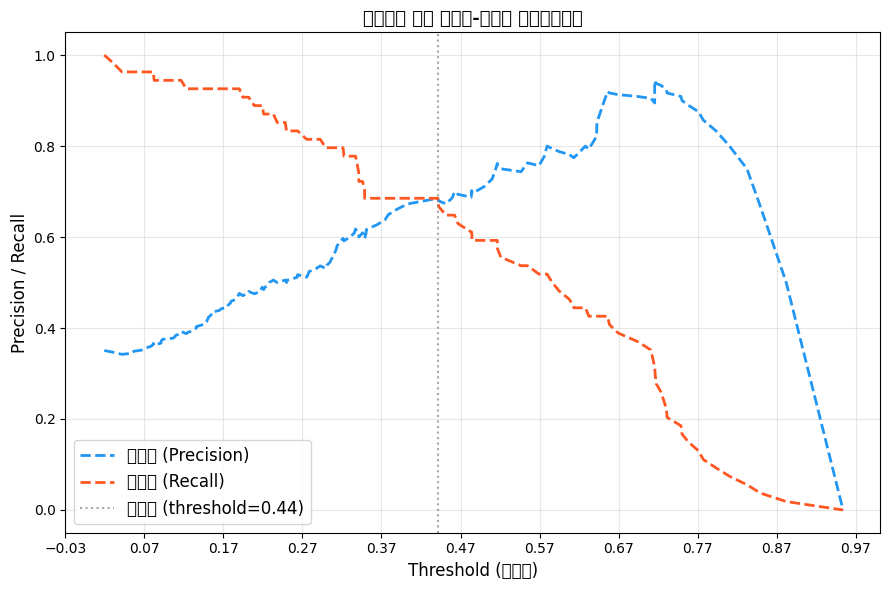

In [16]:
# 정밀도-재현율 곡선으로 최적 임계값 탐색
precision, recalls, thresholds = precision_recall_curve(y_test, pred_proba[:, 1])

# 정밀도 곡선 그리기
plt.figure(figsize=(9, 6))
n = thresholds.shape[0]
plt.plot(thresholds, precision[:n], linestyle='--', label='정밀도 (Precision)',
         color='#2196F3', linewidth=2)

# 재현율 곡선 그리기
plt.plot(thresholds, recalls[:n], linestyle='--', label='재현율 (Recall)',
         color='#FF5722', linewidth=2)
cross_idx = np.argmin(np.abs(precision[:n] - recalls[:n])) # 정밀도와 재현율 차이의 절댓값이 가장 작은
plt.axvline(thresholds[cross_idx], color='gray', linestyle=':',alpha=0.7,
            label=f'교차점 (threshold={thresholds[cross_idx]:.2f})') # 두 곡선의 교차점 (정밀도=재현율) 표시
start, end = plt.xlim() # x축 범위 가져오기
plt.xticks(np.round(np.arange(start, end, 0.1),2))
plt.xlabel('Threshold (임계값)', fontsize=12)
plt.ylabel('Precision / Recall', fontsize=12)
plt.title('임계값에 따른 정밀도-재현율 트레이드오프', fontsize=13, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# 임계값 세밀하게 탐색
thresholds = [0.30, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba_positive = lr_clf.predict_proba(X_test)[:, 1] # 양성 클래스 예측 확률만 추출

print('임계값별 성능 비교')
for threshold in thresholds: # Binarizer는 임계값(threshold)을 기준으로 0 또는 1의 이진 값으로 변환
  binarizer = Binarizer(threshold=threshold).fit(pred_proba_positive.reshape(-1, 1)) # Binarizer에 맞게 2D 배열로 변환
  pred = binarizer.transform(pred_proba_positive.reshape(-1,1)) # 임계값 기준으로 이진 예측 레이블 생성
  print(f'\n임계값: {threshold}')
  # 생성된 예측 레이블과 실제 레이블로 모델 성능 평가 (AUC 포함)
  confusion = confusion_matrix(y_test, pred)  # 오차 행렬 계산
  accuracy = accuracy_score(y_test, pred)     # 정확도 계산
  precision = precision_score(y_test, pred)   # 정밀도 계산
  recall = recall_score(y_test, pred)         # 재현율 계산
  f1 = f1_score(y_test, pred)                 # F1 스코어 계산
  roc_auc = roc_auc_score(y_test, pred_proba_positive) # AUC 계산 (양성 클래스 예측 확률만 사용)

  print('오차 행렬')
  print(confusion)
  TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
  print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
  print(f'\nFN(위음성): {FN} TP(진양성): {TP}')

  print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

임계값별 성능 비교

임계값: 0.3
오차 행렬
[[63 37]
 [11 43]]

TN(진음성): 63 FP(위양성): 37

FN(위음성): 11 TP(진양성): 43
정확도:0.6883, 정밀도:0.5375, 재현율:0.7963, F1:0.6418, AUC:0.8083

임계값: 0.33
오차 행렬
[[72 28]
 [12 42]]

TN(진음성): 72 FP(위양성): 28

FN(위음성): 12 TP(진양성): 42
정확도:0.7403, 정밀도:0.6000, 재현율:0.7778, F1:0.6774, AUC:0.8083

임계값: 0.36
오차 행렬
[[78 22]
 [17 37]]

TN(진음성): 78 FP(위양성): 22

FN(위음성): 17 TP(진양성): 37
정확도:0.7468, 정밀도:0.6271, 재현율:0.6852, F1:0.6549, AUC:0.8083

임계값: 0.39
오차 행렬
[[82 18]
 [17 37]]

TN(진음성): 82 FP(위양성): 18

FN(위음성): 17 TP(진양성): 37
정확도:0.7727, 정밀도:0.6727, 재현율:0.6852, F1:0.6789, AUC:0.8083

임계값: 0.42
오차 행렬
[[83 17]
 [17 37]]

TN(진음성): 83 FP(위양성): 17

FN(위음성): 17 TP(진양성): 37
정확도:0.7792, 정밀도:0.6852, 재현율:0.6852, F1:0.6852, AUC:0.8083

임계값: 0.45
오차 행렬
[[83 17]
 [19 35]]

TN(진음성): 83 FP(위양성): 17

FN(위음성): 19 TP(진양성): 35
정확도:0.7662, 정밀도:0.6731, 재현율:0.6481, F1:0.6604, AUC:0.8083

임계값: 0.48
오차 행렬
[[85 15]
 [21 33]]

TN(진음성): 85 FP(위양성): 15

FN(위음성): 21 TP(진양성): 33
정확도:0.7662, 정밀도:0.6875, 재현율:0.6111, F1:0

In [30]:
# 최적 임계값: 0.42
# 기본값(0.5)보다 낮음 -> 재현율 약간 향상
# 정밀도와 재현율의 균형점

binarizer_final = Binarizer(threshold=0.42)
pred_final = binarizer_final.fit_transform(pred_proba_positive.reshape(-1,1)) #최종적으로 0 또는 1로 이진화된 예측 레이블이 저장
print('최적 임계값 적용 최종 평가')
confusion = confusion_matrix(y_test, pred_final)  # 오차 행렬 계산
accuracy = accuracy_score(y_test, pred_final)     # 정확도 계산
precision = precision_score(y_test, pred_final)   # 정밀도 계산
recall = recall_score(y_test, pred_final)         # 재현율 계산
f1 = f1_score(y_test, pred_final)                 # F1 스코어 계산
roc_auc = roc_auc_score(y_test, pred_proba_positive) # AUC 계산 (양성 클래스 예측확률만 사용)

print('오차 행렬')
print(confusion)
TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
print(f'\nTN(진음성): {TN} FP(위양성): {FP}')
print(f'\nFN(위음성): {FN} TP(진양성): {TP}')

print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

최적 임계값 적용 최종 평가
오차 행렬
[[83 17]
 [17 37]]

TN(진음성): 83 FP(위양성): 17

FN(위음성): 17 TP(진양성): 37
정확도:0.7792, 정밀도:0.6852, 재현율:0.6852, F1:0.6852, AUC:0.8083


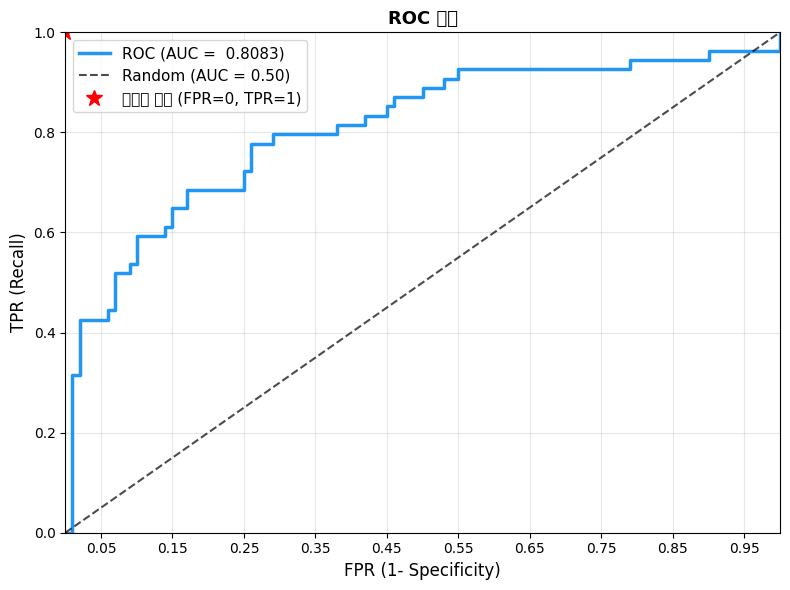

In [32]:
# 최종 ROC 곡선 및 AUC 확인
fprs, tprs, _ = roc_curve(y_test, pred_proba_positive) # _ 는 임계값 사용하지 않기에
auc_val = roc_auc_score(y_test, pred_proba_positive)

plt.figure(figsize=(8, 6))
plt.plot(fprs, tprs, label=f'ROC (AUC = {auc_val: .4f})', color='#2196F3', linewidth=2.5)
plt.plot([0,1],[0,1], 'k--', label='Random (AUC = 0.50)', linewidth=1.5, alpha=0.7) # (0,0)에서 (1,1)까지
plt.plot(0, 1, 'r*', markersize=12, label='완벽한 모델 (FPR=0, TPR=1)') # 완벽한 모델 위치 표시: FPR=0, TPR=1

start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1),2))
plt.xlim(0, 1) # x, y축 범위를 0에서 1로 고정
plt.ylim(0, 1)
plt.xlabel('FPR (1- Specificity)', fontsize=12)
plt.ylabel('TPR (Recall)', fontsize=12)
plt.title('ROC 곡선', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# 0값을 가진 피처별 비율 확인
zero_features = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
total_count = len(diabetes_data)

print('0값이 있는 피처별 건수와 비율:')
for feat in zero_features:
  zero_cnt = (diabetes_data[feat] == 0).sum()
  pct = 100 * zero_cnt / total_count # 0값의 비율 계산
  # 시각적인 막대로 표시하기 위해 유니코드 블록 문자 사용
  visual_bar = '█' * int(pct / 2) # 퍼센트의 절반만큼 블록 문자를 반복
  print(f' {feat:25}: {zero_cnt:3d}건 ({pct:.1f}%) {visual_bar}')

0값이 있는 피처별 건수와 비율:
 Glucose                  :   5건 (0.7%) 
 BloodPressure            :  35건 (4.6%) ██
 SkinThickness            : 227건 (29.6%) ██████████████
 Insulin                  : 374건 (48.7%) ████████████████████████
 BMI                      :  11건 (1.4%) 


In [36]:
# 0값 -> 평균값 대체
mean_zero = diabetes_data[zero_features].mean() # 각 피처의 평균 계산
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero)
zero_after = {f: (diabetes_data[f] == 0).sum() for f in zero_features}
print('대체 후 0값 개수:', zero_after)

대체 후 0값 개수: {'Glucose': np.int64(0), 'BloodPressure': np.int64(0), 'SkinThickness': np.int64(0), 'Insulin': np.int64(0), 'BMI': np.int64(0)}


In [38]:
from sklearn.preprocessing import StandardScaler

# 표준화: 모든 피처를 평균=0, 표준편차=1로 변환
# 로지스틱 회귀는 스케일에 민감하므로 표준화 후 성능 향상
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train 데이터와 test 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=156, stratify=y)

lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀 모델 객체 생성
lr_clf.fit(X_train, y_train) # train 데이터로 모델 학습

pred = lr_clf.predict(X_test) # test 데이터에 대한 예측 레이블 생성
pred_proba = lr_clf.predict_proba(X_test)[:, 1] # 예측 확률 [음성, 양성] -> 양성(당뇨, 1) 클래스 예측 확률
pred_proba

array([0.0050662 , 0.19078324, 0.13315681, 0.55569285, 0.03352927,
       0.72874778, 0.82997075, 0.14932544, 0.17038765, 0.11277607,
       0.69337599, 0.46383968, 0.0456937 , 0.39465543, 0.2425751 ,
       0.09051856, 0.78072871, 0.19137002, 0.01654562, 0.79716262,
       0.42837299, 0.32850869, 0.05311701, 0.30588297, 0.28977835,
       0.10631804, 0.91707487, 0.75349365, 0.18420777, 0.88804531,
       0.19887509, 0.22096444, 0.1142337 , 0.16204273, 0.10839596,
       0.71843899, 0.22416802, 0.43522384, 0.84347292, 0.67783055,
       0.44387035, 0.26061201, 0.70017461, 0.13975146, 0.35177478,
       0.0198151 , 0.68984428, 0.0860875 , 0.5130884 , 0.30086502,
       0.28836211, 0.91333309, 0.89286387, 0.05868155, 0.13928784,
       0.37785524, 0.07477822, 0.37808397, 0.33077705, 0.41917814,
       0.17502616, 0.81636724, 0.32063434, 0.64630775, 0.2855275 ,
       0.0933899 , 0.23460507, 0.73228233, 0.14490675, 0.78387843,
       0.05968644, 0.33104091, 0.11463611, 0.44506076, 0.77036

### F1-score 사용 이유
위기 상황을 얼마나 잘 맞추는지 분류(Classification) 문제를 풀 때
* 주차장 만차
* 자전거 부족
* 지하철 매우혼잡

In [33]:
# 의학 데이터에서 혈당, 혈압 등이 0이면 측정 불가 = 결측치
print('기술통계:')
display(diabetes_data.describe())

기술통계:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000
